# Imports

In [1]:
import os
import time
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torchsummary import summary

from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import Flowers102
from torchvision import transforms
from tqdm.auto import tqdm

### Random seeding and set device

In [2]:
seed_value = 42

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(seed_value)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Dataset loading

In [3]:
data_root = "./data"

flowers_train_raw = Flowers102(root=data_root, split="train", download=True)
flowers_val_raw = Flowers102(root=data_root, split="val", download=True)
flowers_test_raw = Flowers102(root=data_root, split="test", download=True)

print("Number of training samples:", len(flowers_train_raw))
print("Number of validation samples:", len(flowers_val_raw))
print("Number of test samples:", len(flowers_test_raw))

Number of training samples: 1020
Number of validation samples: 1020
Number of test samples: 6149


# Pre-Processing

In [ ]:
train_image_transform = transforms.Compose([
    # Resize to 64x64
    transforms.RandomResizedCrop(64, scale=(0.75, 1.0), ratio=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.02),
])

eval_image_transform = transforms.Compose([
    transforms.Resize((64, 64)),
])

class FlowersLabColorizationDataset(Dataset):
    def __init__(self, base_dataset, image_transform=None):
        self.base_dataset = base_dataset
        self.image_transform = image_transform

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        pil_img, label = self.base_dataset[idx]

        if self.image_transform is not None:
            pil_img = self.image_transform(pil_img)

        rgb = np.array(pil_img, dtype=np.uint8)
        lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB).astype(np.float32)

        l_channel = lab[:, :, 0:1] / 255.0
        ab_channels = (lab[:, :, 1:3] - 128.0) / 128.0

        l_tensor = torch.from_numpy(l_channel.transpose(2, 0, 1))
        ab_tensor = torch.from_numpy(ab_channels.transpose(2, 0, 1))

        return l_tensor, ab_tensor, label

### Create dataloaders

In [5]:
train_dataset = FlowersLabColorizationDataset(flowers_train_raw, image_transform=train_image_transform)
val_dataset = FlowersLabColorizationDataset(flowers_val_raw, image_transform=eval_image_transform)
test_dataset = FlowersLabColorizationDataset(flowers_test_raw, image_transform=eval_image_transform)

batch_size = 32
num_workers = 0 if os.name == "nt" else 2
pin_memory = torch.cuda.is_available()

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=pin_memory)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)
test_loader = DataLoader(test_dataset, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)

In [6]:
print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 32
Validation batches: 32
Test batches: 6149


# Model

In [7]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

class ColorizationAE(nn.Module):
    def __init__(self, base_channels=32):
        super().__init__()

        c1 = base_channels
        c2 = base_channels * 2
        c3 = base_channels * 4
        c4 = base_channels * 6

        self.enc1 = ConvBlock(1, c1)
        self.down1 = nn.Sequential(
            nn.Conv2d(c1, c2, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(c2),
            nn.ReLU(inplace=True),
        )

        self.enc2 = ConvBlock(c2, c2)
        self.down2 = nn.Sequential(
            nn.Conv2d(c2, c3, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(c3),
            nn.ReLU(inplace=True),
        )

        self.enc3 = ConvBlock(c3, c3)
        self.down3 = nn.Sequential(
            nn.Conv2d(c3, c4, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(c4),
            nn.ReLU(inplace=True),
        )

        self.bottleneck = ConvBlock(c4, c4)

        self.up3 = nn.Sequential(
            nn.ConvTranspose2d(c4, c3, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(c3),
            nn.ReLU(inplace=True),
        )
        self.dec3 = ConvBlock(c3, c3)

        self.up2 = nn.Sequential(
            nn.ConvTranspose2d(c3, c2, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(c2),
            nn.ReLU(inplace=True),
        )
        self.dec2 = ConvBlock(c2, c2)

        self.up1 = nn.Sequential(
            nn.ConvTranspose2d(c2, c1, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(c1),
            nn.ReLU(inplace=True),
        )
        self.dec1 = ConvBlock(c1, c1)

        self.out_conv = nn.Conv2d(c1, 2, kernel_size=1)

    def forward(self, l_channel):
        x = self.enc1(l_channel)
        x = self.down1(x)

        x = self.enc2(x)
        x = self.down2(x)

        x = self.enc3(x)
        x = self.down3(x)

        x = self.bottleneck(x)

        x = self.up3(x)
        x = self.dec3(x)

        x = self.up2(x)
        x = self.dec2(x)

        x = self.up1(x)
        x = self.dec1(x)

        ab_out = torch.tanh(self.out_conv(x))
        return ab_out

def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [8]:
ae_model = ColorizationAE(base_channels=32).to(device)
total_params = count_trainable_parameters(ae_model)

### Count parameters

In [9]:
print("AE trainable parameters:", total_params)

print("\nModel summary:")
summary(ae_model, (1, 64, 64))

AE trainable parameters: 2548610

Model summary:
Layer (type:depth-idx)                   Output Shape              Param #
├─ConvBlock: 1-1                         [-1, 32, 64, 64]          --
|    └─Sequential: 2-1                   [-1, 32, 64, 64]          --
|    |    └─Conv2d: 3-1                  [-1, 32, 64, 64]          320
|    |    └─BatchNorm2d: 3-2             [-1, 32, 64, 64]          64
|    |    └─ReLU: 3-3                    [-1, 32, 64, 64]          --
|    |    └─Conv2d: 3-4                  [-1, 32, 64, 64]          9,248
|    |    └─BatchNorm2d: 3-5             [-1, 32, 64, 64]          64
|    |    └─ReLU: 3-6                    [-1, 32, 64, 64]          --
├─Sequential: 1-2                        [-1, 64, 32, 32]          --
|    └─Conv2d: 2-2                       [-1, 64, 32, 32]          32,832
|    └─BatchNorm2d: 2-3                  [-1, 64, 32, 32]          128
|    └─ReLU: 2-4                         [-1, 64, 32, 32]          --
├─ConvBlock: 1-3           

Layer (type:depth-idx)                   Output Shape              Param #
├─ConvBlock: 1-1                         [-1, 32, 64, 64]          --
|    └─Sequential: 2-1                   [-1, 32, 64, 64]          --
|    |    └─Conv2d: 3-1                  [-1, 32, 64, 64]          320
|    |    └─BatchNorm2d: 3-2             [-1, 32, 64, 64]          64
|    |    └─ReLU: 3-3                    [-1, 32, 64, 64]          --
|    |    └─Conv2d: 3-4                  [-1, 32, 64, 64]          9,248
|    |    └─BatchNorm2d: 3-5             [-1, 32, 64, 64]          64
|    |    └─ReLU: 3-6                    [-1, 32, 64, 64]          --
├─Sequential: 1-2                        [-1, 64, 32, 32]          --
|    └─Conv2d: 2-2                       [-1, 64, 32, 32]          32,832
|    └─BatchNorm2d: 2-3                  [-1, 64, 32, 32]          128
|    └─ReLU: 2-4                         [-1, 64, 32, 32]          --
├─ConvBlock: 1-3                         [-1, 64, 32, 32]          --
|    └

## Loss function

Weighted sum of:
- Reconstruction loss (L1 on a and b channels)
- Histogram loss
- Saturation loss

In [10]:
def soft_histogram(x, bins=32, min_val=-1.0, max_val=1.0, sigma=0.02):
    x_flat = x.reshape(x.shape[0], -1, 1)
    centers = torch.linspace(min_val, max_val, bins, device=x.device).view(1, 1, bins)
    weights = torch.exp(-0.5 * ((x_flat - centers) / (sigma + 1e-8)) ** 2)
    hist = weights.sum(dim=1)
    hist = hist / (hist.sum(dim=1, keepdim=True) + 1e-8)
    return hist

def colorization_loss(pred_ab, true_ab, lambda_hist=0.02, lambda_sat=0.20):
    recon_loss = F.l1_loss(pred_ab, true_ab)

    pred_hist_a = soft_histogram(pred_ab[:, 0:1, :, :])
    true_hist_a = soft_histogram(true_ab[:, 0:1, :, :])
    pred_hist_b = soft_histogram(pred_ab[:, 1:2, :, :])
    true_hist_b = soft_histogram(true_ab[:, 1:2, :, :])

    hist_loss = F.mse_loss(pred_hist_a, true_hist_a) + F.mse_loss(pred_hist_b, true_hist_b)

    pred_sat = torch.sqrt(torch.clamp(pred_ab[:, 0, :, :] ** 2 + pred_ab[:, 1, :, :] ** 2, min=1e-8))
    true_sat = torch.sqrt(torch.clamp(true_ab[:, 0, :, :] ** 2 + true_ab[:, 1, :, :] ** 2, min=1e-8))
    sat_loss = F.l1_loss(pred_sat, true_sat)

    total_loss = recon_loss + lambda_hist * hist_loss + lambda_sat * sat_loss
    return total_loss, recon_loss, hist_loss, sat_loss

# Training

In [11]:
num_epochs = 30
learning_rate = 8e-4
lambda_hist = 0.02
lambda_sat = 0.20

In [12]:
model = ae_model
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

history = {
    "train_total": [], "train_recon": [], "train_hist": [], "train_sat": [],
    "val_total": [], "val_recon": [], "val_hist": [], "val_sat": [],
}

best_val_loss = float("inf")
best_state_dict = None

start_time = time.time()

epoch_bar = tqdm(range(1, num_epochs + 1), desc="Epochs", leave=True)
for epoch in epoch_bar:
    model.train()
    train_total = 0.0
    train_recon = 0.0
    train_hist = 0.0
    train_sat = 0.0

    train_batch_bar = tqdm(train_loader, desc=f"Train {epoch}/{num_epochs}", leave=False)
    for l_batch, ab_batch, _ in train_batch_bar:
        l_batch = l_batch.to(device)
        ab_batch = ab_batch.to(device)

        pred_ab = model(l_batch)
        loss, recon_loss, hist_loss, sat_loss = colorization_loss(
            pred_ab, ab_batch, lambda_hist=lambda_hist, lambda_sat=lambda_sat
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_total += loss.item()
        train_recon += recon_loss.item()
        train_hist += hist_loss.item()
        train_sat += sat_loss.item()

        train_batch_bar.set_postfix(
            loss=f"{loss.item():.4f}",
            recon=f"{recon_loss.item():.4f}",
            hist=f"{hist_loss.item():.4f}",
            sat=f"{sat_loss.item():.4f}",
        )

    n_train_batches = len(train_loader)
    train_total /= n_train_batches
    train_recon /= n_train_batches
    train_hist /= n_train_batches
    train_sat /= n_train_batches

    model.eval()
    val_total = 0.0
    val_recon = 0.0
    val_hist = 0.0
    val_sat = 0.0

    val_batch_bar = tqdm(val_loader, desc=f"Val {epoch}/{num_epochs}", leave=False)
    with torch.no_grad():
        for l_batch, ab_batch, _ in val_batch_bar:
            l_batch = l_batch.to(device)
            ab_batch = ab_batch.to(device)

            pred_ab = model(l_batch)
            loss, recon_loss, hist_loss, sat_loss = colorization_loss(
                pred_ab, ab_batch, lambda_hist=lambda_hist, lambda_sat=lambda_sat
            )

            val_total += loss.item()
            val_recon += recon_loss.item()
            val_hist += hist_loss.item()
            val_sat += sat_loss.item()

            val_batch_bar.set_postfix(
                loss=f"{loss.item():.4f}",
                recon=f"{recon_loss.item():.4f}",
                hist=f"{hist_loss.item():.4f}",
                sat=f"{sat_loss.item():.4f}",
            )

    n_val_batches = len(val_loader)
    val_total /= n_val_batches
    val_recon /= n_val_batches
    val_hist /= n_val_batches
    val_sat /= n_val_batches

    history["train_total"].append(train_total)
    history["train_recon"].append(train_recon)
    history["train_hist"].append(train_hist)
    history["train_sat"].append(train_sat)
    history["val_total"].append(val_total)
    history["val_recon"].append(val_recon)
    history["val_hist"].append(val_hist)
    history["val_sat"].append(val_sat)

    if val_total < best_val_loss:
        best_val_loss = val_total
        best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    epoch_bar.set_postfix(train=f"{train_total:.4f}", val=f"{val_total:.4f}", best=f"{best_val_loss:.4f}")
    tqdm.write(
        f"Epoch {epoch:03d}/{num_epochs} | "
        f"Train: {train_total:.4f} (recon={train_recon:.4f}, hist={train_hist:.4f}, sat={train_sat:.4f}) | "
        f"Val: {val_total:.4f} (recon={val_recon:.4f}, hist={val_hist:.4f}, sat={val_sat:.4f})"
    )

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)

print(f"Best validation loss: {best_val_loss:.4f}")
print(f"Training time: {time.time() - start_time:.1f} seconds")

Epochs:   0%|          | 0/30 [00:00<?, ?it/s]

Train 1/30:   0%|          | 0/32 [00:00<?, ?it/s]

Val 1/30:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 001/30 | Train: 0.2003 (recon=0.1622, hist=0.0268, sat=0.1881) | Val: 0.1879 (recon=0.1525, hist=0.0327, sat=0.1738)


Train 2/30:   0%|          | 0/32 [00:00<?, ?it/s]

...

Val 29/30:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 029/30 | Train: 0.1498 (recon=0.1238, hist=0.0148, sat=0.1289) | Val: 0.1495 (recon=0.1239, hist=0.0145, sat=0.1264)


Train 30/30:   0%|          | 0/32 [00:00<?, ?it/s]

Val 30/30:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 030/30 | Train: 0.1487 (recon=0.1227, hist=0.0149, sat=0.1283) | Val: 0.1507 (recon=0.1253, hist=0.0144, sat=0.1256)
Best validation loss: 0.1459
Training time: 151.0 seconds


## Plot

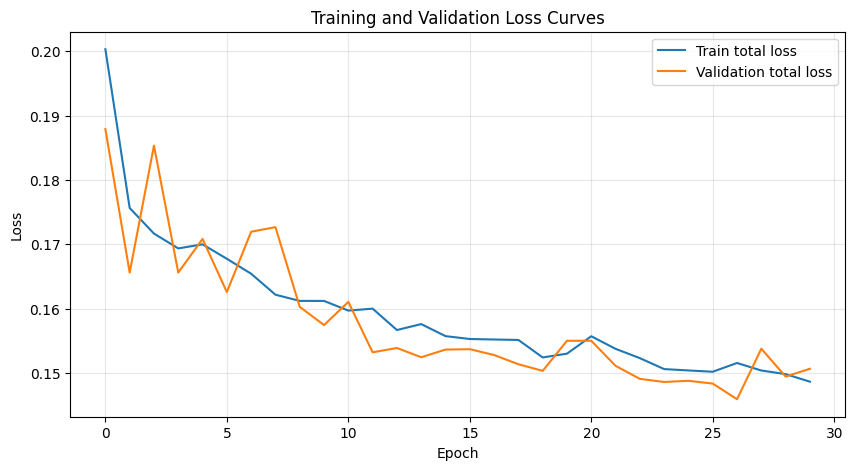

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(history["train_total"], label="Train total loss")
plt.plot(history["val_total"], label="Validation total loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Evaluation

In [14]:
model.eval()

test_l1 = 0.0
test_mse = 0.0

with torch.no_grad():
    test_bar = tqdm(test_loader, desc="Testing", leave=False)
    for l_batch, ab_batch, _ in test_bar:
        l_batch = l_batch.to(device)
        ab_batch = ab_batch.to(device)

        pred_ab = model(l_batch)

        l1_val = F.l1_loss(pred_ab, ab_batch).item()
        mse_val = F.mse_loss(pred_ab, ab_batch).item()

        test_l1 += l1_val
        test_mse += mse_val

        test_bar.set_postfix(l1=f"{l1_val:.4f}", mse=f"{mse_val:.4f}")

test_l1 /= len(test_loader)
test_mse /= len(test_loader)

print(f"Mean reconstruction error (L1) on test set: {test_l1:.6f}")
print(f"Mean reconstruction error (MSE) on test set: {test_mse:.6f}")

Testing:   0%|          | 0/6149 [00:00<?, ?it/s]

Mean reconstruction error (L1) on test set: 0.120360
Mean reconstruction error (MSE) on test set: 0.029128


# Sample output

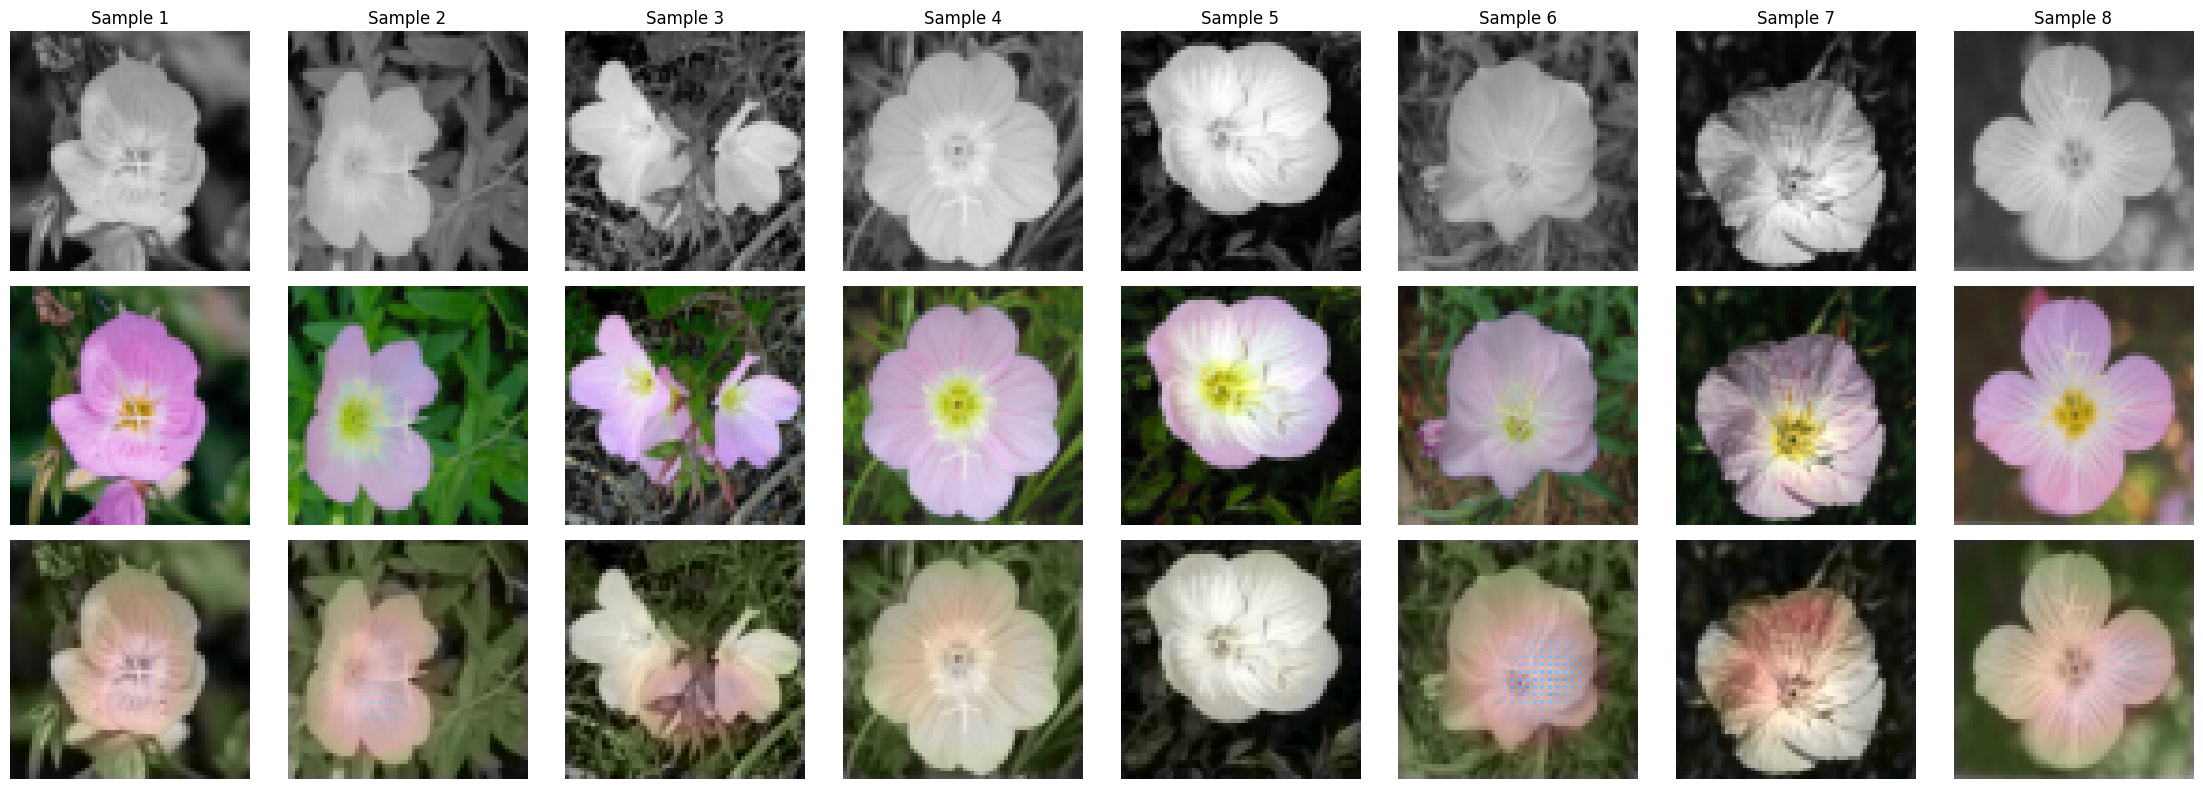

In [15]:
def lab_tensors_to_rgb_uint8(l_tensor_hw, ab_tensor_chw):
    l_np = l_tensor_hw.astype(np.float32)
    ab_np = ab_tensor_chw.transpose(1, 2, 0).astype(np.float32)

    l_uint8 = (np.clip(l_np, 0.0, 1.0) * 255.0).astype(np.uint8)
    ab_uint8 = (np.clip(ab_np, -1.0, 1.0) * 128.0 + 128.0).astype(np.uint8)

    lab = np.concatenate([l_uint8[..., None], ab_uint8], axis=2)
    rgb = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    return rgb

num_show = 8
l_samples = []
ab_true_samples = []

for l_batch, ab_batch, _ in tqdm(test_loader, desc="Collecting samples", leave=False):
    for i in range(l_batch.shape[0]):
        l_samples.append(l_batch[i])
        ab_true_samples.append(ab_batch[i])
        if len(l_samples) >= num_show:
            break
    if len(l_samples) >= num_show:
        break

l_stack = torch.stack(l_samples).to(device)

model.eval()
with torch.no_grad():
    ab_pred_stack = model(l_stack).cpu()

fig, ax = plt.subplots(3, num_show, figsize=(2.8 * num_show, 8))

for i in range(num_show):
    l_np = l_samples[i].squeeze(0).cpu().numpy()
    ab_true_np = ab_true_samples[i].cpu().numpy()
    ab_pred_np = ab_pred_stack[i].cpu().numpy()

    gray_rgb = np.repeat((np.clip(l_np, 0.0, 1.0) * 255.0).astype(np.uint8)[..., None], 3, axis=2)
    gt_rgb = lab_tensors_to_rgb_uint8(l_np, ab_true_np)
    pred_rgb = lab_tensors_to_rgb_uint8(l_np, ab_pred_np)

    ax[0, i].imshow(gray_rgb)
    ax[1, i].imshow(gt_rgb)
    ax[2, i].imshow(pred_rgb)

    ax[0, i].set_title(f"Sample {i + 1}")

    for row in range(3):
        ax[row, i].axis("off")

ax[0, 0].set_ylabel("Input (L / grayscale)", fontsize=11)
ax[1, 0].set_ylabel("Ground Truth (RGB)", fontsize=11)
ax[2, 0].set_ylabel("AE Output (RGB)", fontsize=11)

plt.tight_layout()
plt.show()